# 02 – Data Preprocessing
This notebook handles:
- Missing value imputation
- Feature scaling
- Train/test split
- Clean dataset export

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load dataset
df = pd.read_csv('../data/credit_data.csv')

# Drop unnamed index column if it exists
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

# Preview data
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## Initial Data Overview
We begin by examining the shape, types, and basic statistics of the dataset.

In [7]:
# Check data types and non-null counts
print(df.info())

# Summary statistics
print(df.describe())

# Count of missing values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtype

## Handling Missing Values
We impute:
- `MonthlyIncome` with median
- `NumberOfDependents` with mode


In [8]:
# Impute MonthlyIncome with median
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)

# Impute NumberOfDependents with mode
df['NumberOfDependents'].fillna(df['NumberOfDependents'].mode()[0], inplace=True)

# Verify no missing values remain
print("✅ Missing values handled.")
print(df.isnull().sum())

✅ Missing values handled.
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


C:\Users\hp\AppData\Local\Temp\ipykernel_3420\1419260899.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_3420\1419260899.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

## Correlation Heatmap
This visual helps us understand feature relationships.


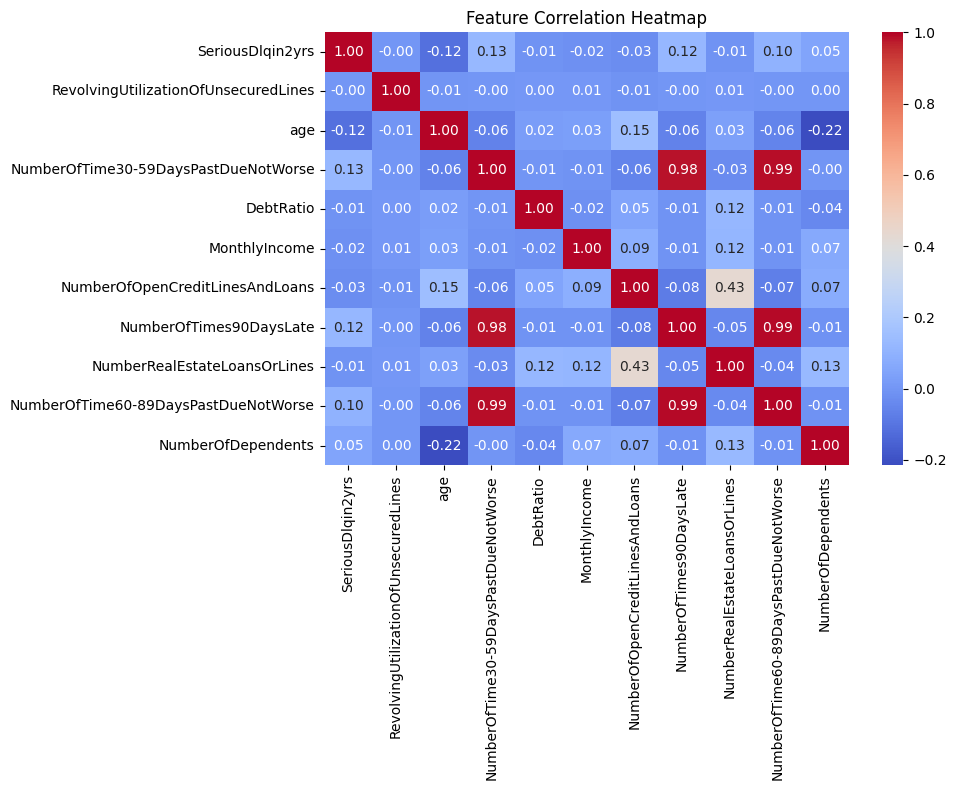

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## Scaling and Train/Test Split
We use `StandardScaler` and stratified splitting.


In [10]:
# Separate features and target
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and test sets (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Save scaler for later use
joblib.dump(scaler, 'models/scaler.joblib')

['models/scaler.joblib']

## Saving Cleaned Dataset
We save the processed dataset to `clean_credit_data.csv`.


In [11]:
# Recombine features and label into one DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
cleaned_df = pd.concat([X_scaled_df, y.reset_index(drop=True)], axis=1)

# Save cleaned data to CSV
cleaned_df.to_csv('../data/clean_credit_data.csv', index=False)

print("✅ Cleaned dataset saved at ../data/clean_credit_data.csv")

✅ Cleaned dataset saved at ../data/clean_credit_data.csv
